# Figure R4: Split heatmaps (accuracy vs tokens)

Splits original Figure 2 into separate accuracy and token heatmaps for clarity.

- **Top row (a--c):** Accuracy heatmaps per model
- **Bottom row (d--f):** Reasoning token heatmaps per model
- **Columns:** o1-mini | o3-mini (m) | o3-mini (h)

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize
from performance_eval import (domain_per_difficulty_performance, domain_per_difficulty_tokens,
                               difficulty_performance, difficulty_tokens,
                               total_performance, total_tokens, value_to_color)

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath, amssymb}"

cm = 1 / 2.54

## Data Loading

In [54]:
TIERS = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']
DOMAINS = ['Algebra', 'Applied Mathematics', 'Calculus', 'Discrete Mathematics', 'Geometry', 'Number Theory']
DOMAINS_SHORT = ['Algebra', 'Applied Math', 'Calculus', 'Discrete Math', 'Geometry', 'Number Theory']

FILES = {
    'o1': 'data/omni-judge_output_o1.jsonl',
    'o3': 'data/omni-judge_output_o3.jsonl',
    'o3h': 'data/omni-judge_output_o3_high.jsonl',
}
MODEL_LABELS = {'o1': r'\textbf{o1-mini}', 'o3': r'\textbf{o3-mini (m)}', 'o3h': r'\textbf{o3-mini (h)}'}

# Build accuracy and token DataFrames for each model
acc_data = {}  # model -> 2D array (domains x tiers)
tok_data = {}  # model -> 2D array (domains x tiers)
tier_acc_data = {}  # model -> 1D array (tiers)
tier_tok_data = {}  # model -> 1D array (tiers)
domain_acc_data = {}  # model -> 1D array (domains)
domain_tok_data = {}  # model -> 1D array (domains)
total_acc_data = {}  # model -> scalar
total_tok_data = {}  # model -> scalar

for model, fpath in FILES.items():
    dpdp = domain_per_difficulty_performance(fpath)
    dpdt = domain_per_difficulty_tokens(fpath)
    dp = difficulty_performance(fpath)
    dt = difficulty_tokens(fpath)
    tp = total_performance(fpath)
    tt = total_tokens(fpath)
    
    acc_grid = np.zeros((len(DOMAINS), len(TIERS)))
    tok_grid = np.zeros((len(DOMAINS), len(TIERS)))
    for j, tier in enumerate(TIERS):
        for i, domain in enumerate(DOMAINS):
            acc_grid[i, j] = dpdp[tier][domain]['accuracy']
            tok_grid[i, j] = dpdt[tier][domain]['avg']
    
    acc_data[model] = acc_grid
    tok_data[model] = tok_grid
    tier_acc_data[model] = np.array([dp[t]['accuracy'] for t in TIERS])
    tier_tok_data[model] = np.array([dt[t]['avg'] for t in TIERS])
    domain_acc_data[model] = acc_grid.mean(axis=1)  # average across tiers
    domain_tok_data[model] = tok_grid.mean(axis=1)
    total_acc_data[model] = tp['accuracy']
    total_tok_data[model] = tt['avg']
    
    print(f'{model}: total acc={tp["accuracy"]:.1f}%, avg tokens={tt["avg"]:.0f}')

o1: total acc=60.3%, avg tokens=4439
{"domain": ["Mathematics -> Geometry -> Plane Geometry -> Polygons"], "difficulty": 7.0, "problem": "Let $ \\mathcal{P}$ be a convex polygon with $ n$ sides, $ n\\ge3$. Any set of $ n \\minus{} 3$ diagonals of $ \\mathcal{P}$ that do not intersect in the interior of the polygon determine a [i]triangulation[/i] of $ \\mathcal{P}$ into $ n \\minus{} 2$ triangles. If $ \\mathcal{P}$ is regular and there is a triangulation of $ \\mathcal{P}$ consisting of only isosceles triangles, find all the possible values of $ n$.", "answer": "\\[ n = 2^a(2^b+1) \\text{ where } a, b \\text{ are nonnegative integers not both zero.} \\]", "model_generation": "", "omni-judge": "## Student Final Answer\n$\\boxed{3}$", "prompt_tokens": 152, "reasoning_tokens": 25000, "completion_tokens": 25000}

{"domain": ["Mathematics -> Geometry -> Plane Geometry -> Polygons"], "difficulty": 7.0, "problem": "Let $ \\mathcal{P}$ be a convex polygon with $ n$ sides, $ n\\ge3$. Any set o

## Figure

In [55]:
# ============================================================
# Colormaps
# ============================================================
color_red = '#D55E00'
color_green = '#009E73'
color_mid = '#F0F0F0'
palette = sns.color_palette("colorblind")

acc_cmap = LinearSegmentedColormap.from_list('acc', [color_red, color_mid, color_green], N=256)

# Token colormap: simple light grey → paper blue
tok_cmap = LinearSegmentedColormap.from_list('tok', [color_mid, palette[0]], N=256)

num_colors = 256
acc_palette = [acc_cmap(i / (num_colors - 1)) for i in range(num_colors)]
tok_palette = [tok_cmap(i / (num_colors - 1)) for i in range(num_colors)]

acc_min, acc_max = 0, 100

# Per-model token ranges for normalization
tok_ranges = {}
for model in FILES:
    all_vals = np.concatenate([
        tok_data[model].ravel(),
        tier_tok_data[model],
        domain_tok_data[model],
        [total_tok_data[model]],
    ])
    tok_ranges[model] = (all_vals.min(), all_vals.max())
    print(f'{model} token range: {all_vals.min():.0f} - {all_vals.max():.0f}')

o1 token range: 1665 - 6806
o3 token range: 1453 - 6176
o3h token range: 3135 - 15698


In [56]:
# ============================================================
# Helper function to draw a heatmap on a given axis
# ============================================================

def _text_color(bg_rgba):
    """Return 'white' or 'black' depending on background luminance."""
    r, g, b = bg_rgba[:3]
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return 'white' if lum < 0.45 else 'black'


def draw_heatmap(ax, grid, palette, vmin, vmax, fmt='{:.0f}', show_y_labels=False, show_x_labels=False,
                 title='', n_colors=256, fontsize_cell=5.5, show_text=True):
    """Draw a domains x tiers heatmap."""
    n_rows, n_cols = grid.shape
    y_names = DOMAINS_SHORT[::-1]
    x_names = TIERS
    y_to_num = {name: i for i, name in enumerate(y_names)}
    x_to_num = {name: i for i, name in enumerate(x_names)}
    
    for i, domain in enumerate(DOMAINS_SHORT):
        for j, tier in enumerate(TIERS):
            val = grid[i, j]
            y_pos = y_to_num[domain]
            x_pos = x_to_num[tier]
            color_fill = value_to_color(val, palette, vmin, vmax, n_colors)
            ax.add_patch(mpatches.Rectangle((x_pos - 0.5, y_pos - 0.5), 1, 1,
                                            facecolor=color_fill, edgecolor='white', linewidth=1))
            if show_text:
                ax.text(x_pos, y_pos, fmt.format(val), ha='center', va='center',
                        fontsize=fontsize_cell, color=_text_color(color_fill))
    
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    
    if show_y_labels:
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels(y_names, fontsize=6)
    else:
        ax.set_yticks([])
    
    if show_x_labels:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(x_names, rotation=45, ha='right', fontsize=6)
    else:
        ax.set_xticks([])
    
    ax.set_title(title, fontsize=7, pad=6)
    ax.grid(False)


def draw_margin_col(ax, values, palette, vmin, vmax, fmt='{:.0f}',
                    show_y_labels=False, n_colors=256, fontsize_cell=5.5, show_text=True):
    """Draw domain average margin column (left of main grid)."""
    y_names = DOMAINS_SHORT[::-1]
    for i, domain in enumerate(DOMAINS_SHORT):
        y_pos = {name: idx for idx, name in enumerate(y_names)}[domain]
        val = values[i]
        color_fill = value_to_color(val, palette, vmin, vmax, n_colors)
        ax.add_patch(mpatches.Rectangle((-0.5, y_pos - 0.5), 1, 1,
                                        facecolor=color_fill, edgecolor='white', linewidth=1))
        if show_text:
            ax.text(0, y_pos, fmt.format(val), ha='center', va='center',
                    fontsize=fontsize_cell, color=_text_color(color_fill))
    
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, len(DOMAINS) - 0.5)
    
    if show_y_labels:
        ax.set_yticks(range(len(DOMAINS)))
        ax.set_yticklabels(y_names, fontsize=6)
        ax.set_ylabel('Domain', fontsize=7)
    else:
        ax.set_yticks([])
    ax.set_xticks([])
    ax.grid(False)


def draw_margin_row(ax, values, palette, vmin, vmax, fmt='{:.0f}',
                    show_x_labels=False, n_colors=256, fontsize_cell=5.5, show_text=True):
    """Draw tier average margin row (below main grid)."""
    for j, tier in enumerate(TIERS):
        val = values[j]
        color_fill = value_to_color(val, palette, vmin, vmax, n_colors)
        ax.add_patch(mpatches.Rectangle((j - 0.5, -0.5), 1, 1,
                                        facecolor=color_fill, edgecolor='white', linewidth=1))
        if show_text:
            ax.text(j, 0, fmt.format(val), ha='center', va='center',
                    fontsize=fontsize_cell, color=_text_color(color_fill))
    
    ax.set_xlim(-0.5, len(TIERS) - 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    
    if show_x_labels:
        ax.set_xticks(range(len(TIERS)))
        ax.set_xticklabels(TIERS, rotation=45, ha='right', fontsize=6)
        ax.set_xlabel('Difficulty', fontsize=7)
    else:
        ax.set_xticks([])
    ax.grid(False)


def draw_total_cell(ax, val, palette, vmin, vmax, fmt='{:.0f}',
                    show_y_label=False, n_colors=256, fontsize_cell=5.5, show_text=True):
    """Draw single total-average cell."""
    color_fill = value_to_color(val, palette, vmin, vmax, n_colors)
    ax.add_patch(mpatches.Rectangle((-0.5, -0.5), 1, 1,
                                    facecolor=color_fill, edgecolor='white', linewidth=1))
    if show_text:
        ax.text(0, 0, fmt.format(val), ha='center', va='center',
                fontsize=fontsize_cell, color=_text_color(color_fill))
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xticks([])
    if show_y_label:
        ax.set_yticks([0])
        ax.set_yticklabels(['Average'], fontsize=6)
    else:
        ax.set_yticks([])
    ax.grid(False)

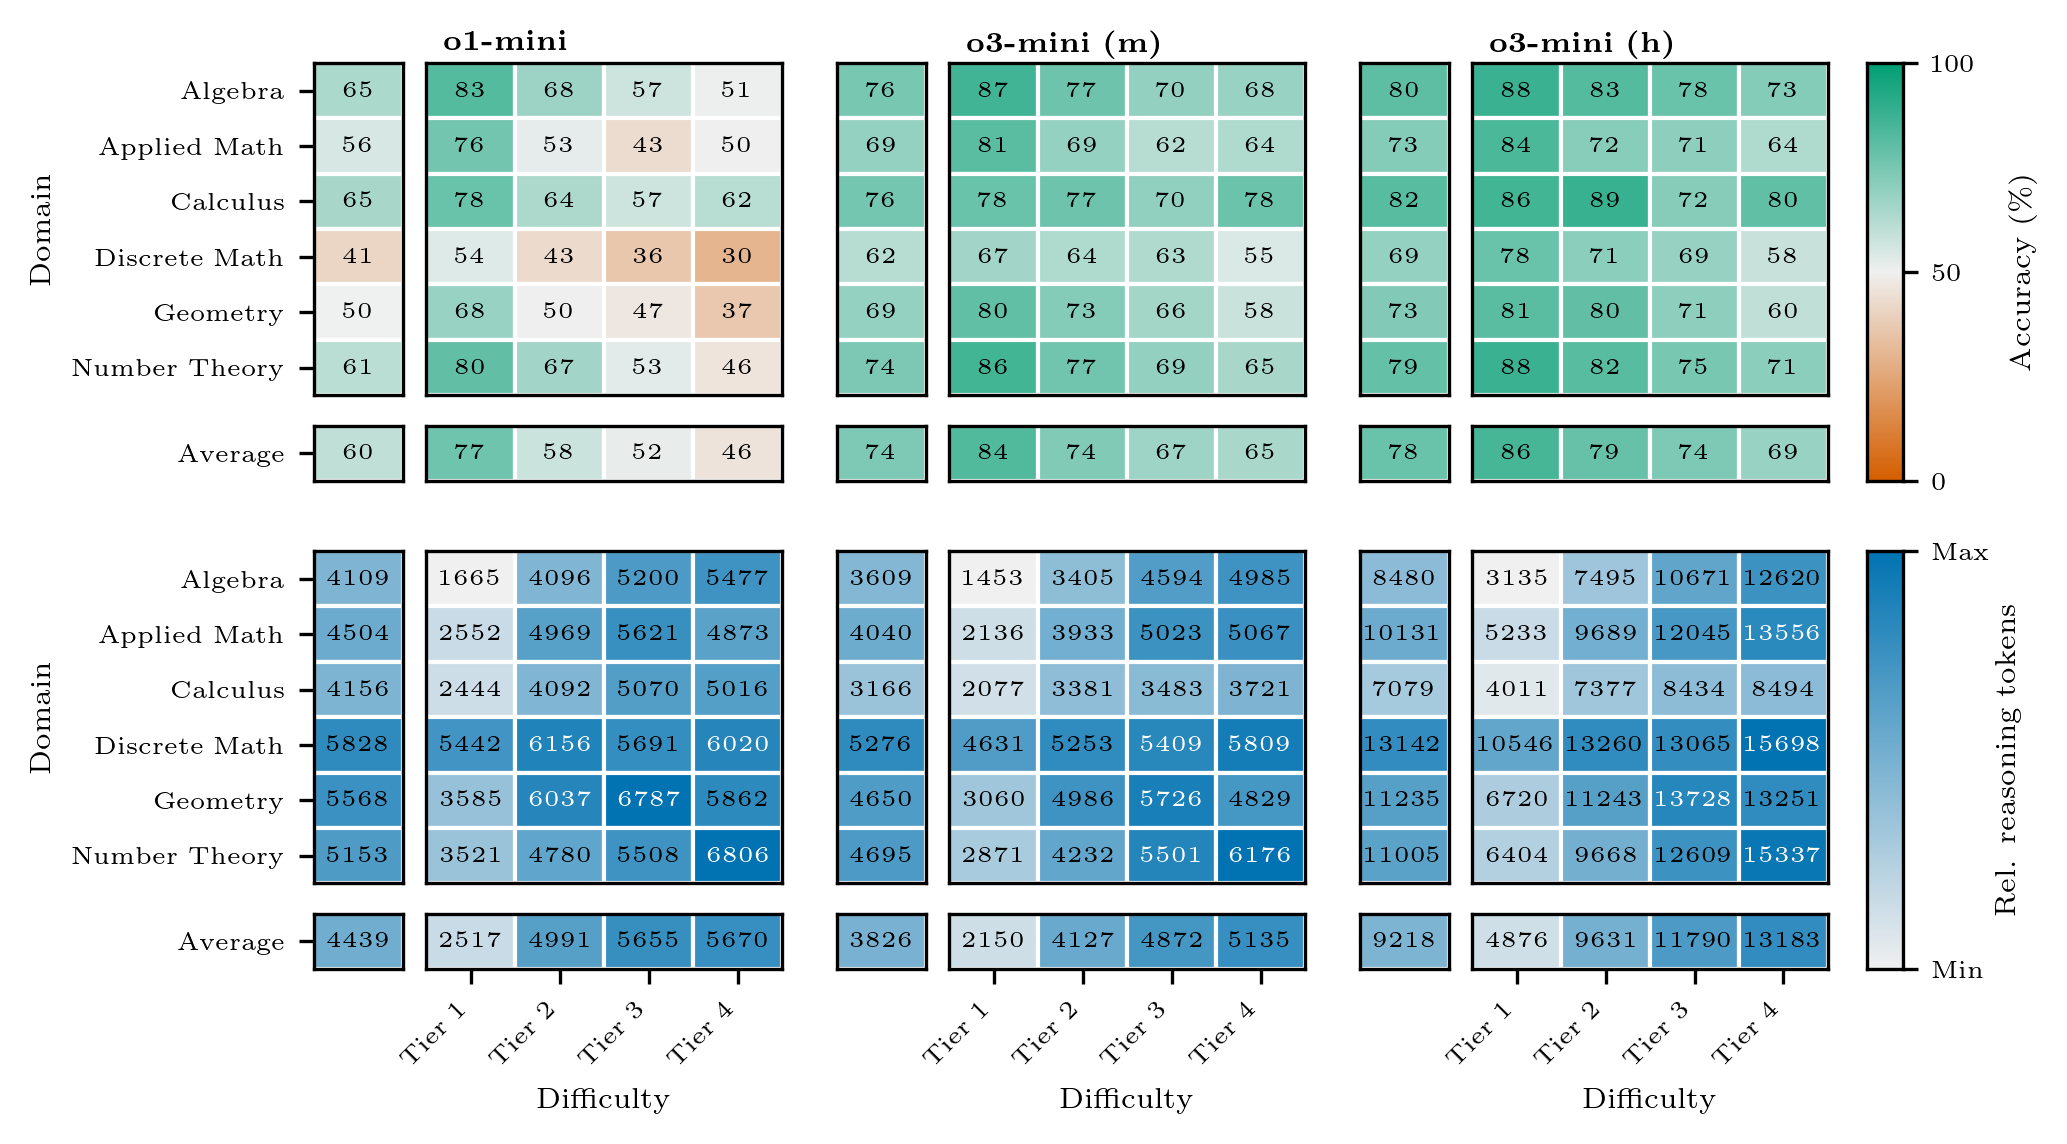

Saved: FigureR4.pdf


In [57]:
# ============================================================
# Layout matching original Figure 2 ratios
# ============================================================

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(6.9, 4.0), dpi=300)

# Two outer rows with reduced vertical gap
outer_gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.12)

models = ['o1', 'o3', 'o3h']

def draw_row(subfig_gs, data_grid, data_domain, data_tier, data_total,
             palette, vmin, vmax, fmt, show_titles, show_xlabels,
             cbar_palette, cbar_vmin, cbar_vmax, cbar_label, cbar_ticks, cbar_ticklabels):
    """Draw one row of 3 heatmaps + colorbar, matching Figure 2 ratios."""
    
    inner = subfig_gs.subgridspec(
        2, 7,
        width_ratios=[0.25, 1, 0.25, 1, 0.25, 1, 0.1],
        height_ratios=[1, 0.166],
        wspace=0.2, hspace=0.25,
    )
    
    ax_keys = [
        (inner[0, 0], inner[0, 1], inner[1, 0], inner[1, 1]),
        (inner[0, 2], inner[0, 3], inner[1, 2], inner[1, 3]),
        (inner[0, 4], inner[0, 5], inner[1, 4], inner[1, 5]),
    ]
    cbar_spec = inner[:, 6]
    
    for idx, model in enumerate(models):
        is_first = (idx == 0)
        mc_spec, main_spec, tot_spec, mr_spec = ax_keys[idx]
        
        ax_main = fig.add_subplot(main_spec)
        ax_mc = fig.add_subplot(mc_spec)
        ax_mr = fig.add_subplot(mr_spec)
        ax_tot = fig.add_subplot(tot_spec)
        
        m_vmin = vmin[model] if isinstance(vmin, dict) else vmin
        m_vmax = vmax[model] if isinstance(vmax, dict) else vmax
        
        draw_heatmap(ax_main, data_grid[model], palette, m_vmin, m_vmax,
                     fmt=fmt, title='')
        
        if show_titles:
            ax_main.text(0.05, 1.1, MODEL_LABELS[model], ha='left', weight='bold',
                         va='top', transform=ax_main.transAxes, fontsize=7)
        
        draw_margin_col(ax_mc, data_domain[model], palette, m_vmin, m_vmax,
                        fmt=fmt, show_y_labels=is_first)
        
        draw_margin_row(ax_mr, data_tier[model], palette, m_vmin, m_vmax,
                        fmt=fmt, show_x_labels=show_xlabels)
        
        draw_total_cell(ax_tot, data_total[model], palette, m_vmin, m_vmax,
                        fmt=fmt, show_y_label=is_first)
        
        pos_mc = ax_mc.get_position()
        ax_mc.set_position([pos_mc.x0 + 0.0075, pos_mc.y0, pos_mc.width, pos_mc.height])
        pos_tot = ax_tot.get_position()
        ax_tot.set_position([pos_tot.x0 + 0.0075, pos_tot.y0 + 0.015, pos_tot.width, pos_tot.height])
        pos_mr = ax_mr.get_position()
        ax_mr.set_position([pos_mr.x0, pos_mr.y0 + 0.015, pos_mr.width, pos_mr.height])
    
    ax_cbar = fig.add_subplot(cbar_spec)
    gradient = np.linspace(0, 1, num_colors).reshape(num_colors, 1)
    ax_cbar.imshow(gradient, aspect='auto', cmap=ListedColormap(cbar_palette))
    ax_cbar.set_xticks([])
    ax_cbar.set_yticks(cbar_ticks)
    ax_cbar.set_yticklabels(cbar_ticklabels, fontsize=6)
    ax_cbar.yaxis.tick_right()
    ax_cbar.set_ylim(0, num_colors - 1)
    
    pos_cb = ax_cbar.get_position()
    ax_cbar.set_position([pos_cb.x0, pos_cb.y0 + 0.015, pos_cb.width, pos_cb.height - 0.015])
    
    pos_cb = ax_cbar.get_position()
    xb, yb, wb, hb = pos_cb.bounds
    ax_cbar.text(
        yb + hb + 3, num_colors / 2, s=cbar_label,
        rotation=90, ha='center', va='center', fontsize=7
    )


# Top row: Accuracy heatmaps
draw_row(
    outer_gs[0],
    acc_data, domain_acc_data, tier_acc_data, total_acc_data,
    acc_palette, acc_min, acc_max, '{:.0f}',
    show_titles=True, show_xlabels=False,
    cbar_palette=acc_palette, cbar_vmin=acc_min, cbar_vmax=acc_max,
    cbar_label=r'Accuracy ($\%$)',
    cbar_ticks=np.linspace(0, num_colors - 1, 3),
    cbar_ticklabels=[f'{v:.0f}' for v in np.linspace(acc_min, acc_max, 3)],
)

# Bottom row: Token heatmaps (per-model normalization)
tok_vmin = {m: tok_ranges[m][0] for m in models}
tok_vmax = {m: tok_ranges[m][1] for m in models}

draw_row(
    outer_gs[1],
    tok_data, domain_tok_data, tier_tok_data, total_tok_data,
    tok_palette, tok_vmin, tok_vmax, '{:.0f}',
    show_titles=False, show_xlabels=True,
    cbar_palette=tok_palette, cbar_vmin=0, cbar_vmax=1,
    cbar_label=r'Rel. reasoning tokens',
    cbar_ticks=[0, num_colors - 1],
    cbar_ticklabels=['Min', 'Max'],
)

plt.savefig('figures/FigureR4.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: FigureR4.pdf')